In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
import matplotlib.ticker as mtick
import seaborn as sns
import re

In [2]:
#df = RNLI_Return_of_Servicev FILTERED PORTHCAWL 2021 - 2025.csv
#df2 = RNLI_Return_of_Service_WALES.csv

df = pd.read_csv('RNLI_Return_of_Servicev FILTERED PORTHCAWL 2021 - 2025.csv')

In [3]:
df.head()

,ObjectID,ROSNumber,LifeboatStationNameProper,AIC,YearofCall,LifeboatClass,LifeboatNumber,RoSType,CasualtyCategory,CasualtyTypeFull,...,SeaConditionsAtLaunch,WindDirectionAtLaunch,ArrivedOnScene,x,y,Date of Launch,Time of Launch,Date Time of Launch,x2,y2
0,172836,LBI08224/2021,Porthcawl,Other,2021,ATLANTIC 85,B-832,ILB,PEOPLE,Other,...,NaN,315.0,Yes,-3.581540,51.426940,2021-10-10,18:23:00,10/10/2021 5:23:00 PM,-3.581540,51.426940
1,140536,LBI07699/2025,Porthcawl,Person in water,2025,ATLANTIC 85,B-832,ILB,PEOPLE,Person in water,...,NaN,90.0,Yes,-3.744859,51.497685,2025-08-19,13:35:00,8/19/2025 12:35:00 PM,-3.744859,51.497685
2,171957,LBI09455/2021,Porthcawl,Commercial fishing,2021,ATLANTIC 85,B-832,ILB,PEOPLE,Commercial fishing,...,NaN,45.0,Yes,-3.844630,51.462400,2021-11-22,13:09:00,11/22/2021 1:09:00 PM,-3.844630,51.462400
3,165628,LBI07854/2022,Porthcawl,Kayak/canoe,2022,ATLANTIC 85,B-832,ILB,LEISURE,Kayak/canoe,...,NaN,270.0,Yes,-3.678980,51.473580,2022-08-09,17:21:00,8/9/2022 4:21:00 PM,-3.678980,51.473580
4,140419,LBI07931/2025,Porthcawl,Mass rescue,2025,ATLANTIC 85,B-832,ILB,PEOPLE,Mass rescue,...,NaN,135.0,Yes,-3.637503,51.470053,2025-08-24,18:27:00,8/24/2025 5:27:00 PM,-3.637503,51.470053


In [4]:
df['AIC'].value_counts()

AIC
Person in distress     59
Paddleboard            41
Person in water        39
Motorboat              31
Walker/runner          29
Swimmer                24
Kayak/canoe            19
Person ashore          18
Mass rescue            15
Waterside activity     13
False alarm            13
Other                  11
Surfboard              10
Angler from boat        9
Unknown person          8
Windsurf                8
Inflatable              6
Kitesurf                6
Jet ski                 6
Bodyboard               5
Animal (dog)            5
Climber                 4
Angler from shore       3
Person on craft         3
Waterskier              2
Commercial activity     1
Animal (other)          1
Commercial fishing      1
Aircraft                1
Unknown Craft           1
Name: count, dtype: int64

In [5]:
df = df.rename(columns={
    'AIC': 'Incident_Category'
})

In [6]:
df.columns

Index(['ObjectID', 'ROSNumber', 'LifeboatStationNameProper',
       'Incident_Category', 'YearofCall', 'LifeboatClass', 'LifeboatNumber',
       'RoSType', 'CasualtyCategory', 'CasualtyTypeFull', 'ReasonforLaunch',
       'OutcomeOfService', 'VisibilityAtIncident', 'WeatherAtIncident',
       'SeaConditionsAtIncident', 'WindDirectionAtIncident',
       'VisibilityAtLaunch', 'WeatherAtLaunch', 'SeaConditionsAtLaunch',
       'WindDirectionAtLaunch', 'ArrivedOnScene', 'x', 'y', 'Date of Launch',
       'Time of Launch', 'Date Time of Launch', 'x2', 'y2'],
      dtype='object')

In [7]:
df['Incident_Category'].value_counts()

Incident_Category
Person in distress     59
Paddleboard            41
Person in water        39
Motorboat              31
Walker/runner          29
Swimmer                24
Kayak/canoe            19
Person ashore          18
Mass rescue            15
Waterside activity     13
False alarm            13
Other                  11
Surfboard              10
Angler from boat        9
Unknown person          8
Windsurf                8
Inflatable              6
Kitesurf                6
Jet ski                 6
Bodyboard               5
Animal (dog)            5
Climber                 4
Angler from shore       3
Person on craft         3
Waterskier              2
Commercial activity     1
Animal (other)          1
Commercial fishing      1
Aircraft                1
Unknown Craft           1
Name: count, dtype: int64

In [8]:
# Create a dictionary mapping: {'Old Value': 'New Combined Value'}
category_mapping = {
    'Kayak/canoe': 'Small Leisure Craft',
    'Sailing': 'Small Leisure Craft',
    'Jet ski' : 'Motorboat',
    'Person on craft' : 'Small Leisure Craft',
    'Surfboard': 'Water Sports',
    'Paddleboard': 'Water Sports',
    'Waterskier' : 'Water Sports',
    'Bodyboard' : 'Water Sports',
    'Windsurf' : 'Water Sports',
    'Kitesurf' : 'Water Sports',
    'Swimmer' : 'Person in distress',
    'Inflatable' : 'Waterside activity',
    'Climber' : 'Waterside activity',
    'Angler from shore' : 'Fishing',
    'Angler from boat' : 'Fishing',
    'Commercial fishing' : 'Fishing',    
    'Person in water' : 'Person in distress',
    'Mass rescue': 'Person in distress',
    'Person ashore' : 'Person in distress',
    'Walker/runner' : 'Person in distress',
    'Person in water' : 'Person in distress',
    'Person in water ' : 'Person in distress',
    'Unknown person' : 'Person in distress',
    'Animal (dog)' : 'Other',
    'Animal (other)' : 'Other',
    'Unknown Craft' : 'Small Leisure Craft',
    'Aircraft' : 'Other',
    'Commercial activity' : 'Other'
    
}

# Apply the replace function. 

df['Incident_Category'] = df['Incident_Category'].replace(category_mapping)

# Check the results
print(df['Incident_Category'].value_counts())

Incident_Category
Person in distress     192
Water Sports            72
Motorboat               37
Small Leisure Craft     23
Waterside activity      23
Other                   19
Fishing                 13
False alarm             13
Name: count, dtype: int64


In [9]:
#ALL WALES dataset
df2 = pd.read_csv('RNLI_Return_of_Service_WALES.csv')

In [10]:
df2 = df2.rename(columns={
    'AIC': 'Incident_Category'
})

In [11]:
# Create a dictionary mapping: {'Old Value': 'New Combined Value'}
category_mapping = {
    'Kayak/canoe': 'Small Leisure Craft',
    'Sailing': 'Small Leisure Craft',
    'Jet ski' : 'Motorboat',
    'Person on craft' : 'Small Leisure Craft',
    'Sailing dinghy' : 'Small Leisure Craft',
    'Sailing vessel' : 'Small Leisure Craft',
    'Rowing boat' : 'Water Sports',
    'Surfboard': 'Water Sports',
    'Paddleboard': 'Water Sports',
    'Waterskier' : 'Water Sports',
    'Bodyboard' : 'Water Sports',
    'Windsurf' : 'Water Sports',
    'Kitesurf' : 'Water Sports',
    'Diving vessel' : 'Motorboat',
    'Distress signals' : 'Motorboat',
    'Swimmer' : 'Person in distress',
    'Inflatable' : 'Waterside activity',
    'Climber' : 'Waterside activity',
    'Coasteerer' : 'Waterside activity',
    'Angler from shore' : 'Fishing',
    'Angler from boat' : 'Fishing',
    'Commercial fishing' : 'Fishing',    
    'Person in water': 'Person in distress',
    'Mass rescue': 'Person in distress',
    'Person ashore' : 'Person in distress',
    'Walker/runner' : 'Person in distress',
    'Person in water' : 'Person in distress',
    'Unknown person' : 'Person in distress',
    'Scuba diver' : 'Person in distress',
    'Animal (dog)' : 'Other',
    'Animal (other)' : 'Other',
    'Unknown Craft' : 'Small Leisure Craft',
    'Aircraft' : 'Other',
    'Commercial activity' : 'Other',
    'Object in the sea' : 'Other',
    'Unknown craft': 'Other',
    'Unknown' : 'Other',
    'Motor vehicle' : 'Other',
    'Tombstoner' : 'Other',   
    
}

# Apply the replace function. 
df2['Incident_Category'] = df2['Incident_Category'].replace(category_mapping)

# Check the results
print(df2['Incident_Category'].value_counts())

Incident_Category
Person in distress     2014
Small Leisure Craft    1212
Motorboat               764
Other                   653
Fishing                 320
Water Sports            296
False alarm             164
Waterside activity      156
Name: count, dtype: int64


# Wales incidents per 1 million coastal visitors

Source: Wales 42 million coastal visitors per year (2025 report) pg 132 https://cdn.cyfoethnaturiol.cymru/f45ehjei/sonarr2025-final-report.pdf

In [12]:
# Wales per beach visitor
annual_visitors = 42_000_000
years = 5
total_exposure = annual_visitors * years

# Get the counts
counts = df2['Incident_Category'].value_counts()

# Create the summary
normalized_data = []

for cat, val in counts.items():
    # Calculate incidents per 1 million visitors
    rate = (val / total_exposure) * 1_000_000
    
    normalized_data.append({
        "Category": cat,
        "Raw Count": val,
        "Rate per 1M Visitors": round(rate, 2)
    })

# Convert to DataFrame for a clean table display
results_df2 = pd.DataFrame(normalized_data)
print(results_df2)

              Category  Raw Count  Rate per 1M Visitors
0   Person in distress       2014                  9.59
1  Small Leisure Craft       1212                  5.77
2            Motorboat        764                  3.64
3                Other        653                  3.11
4              Fishing        320                  1.52
5         Water Sports        296                  1.41
6          False alarm        164                  0.78
7   Waterside activity        156                  0.74


# Porthcawl incidents per 1 million coastal visitors

There is no official souce of annual visitor numbers for Porthcawl specifically. There is only car park data for Rest Bay 115,087 visitors.
https://www.bridgend.gov.uk/media/it1bpb5v/destination-management-plan-2022-2027.pdf

However, this is not even the biggest car park in Porthcawl, and does not account for other modes of transport.

Bridgend county gave an official visitor number for the whole county of 3.7 million annually.

https://www.bridgend.gov.uk/media/it1bpb5v/destination-management-plan-2022-2027.pdf

84% of which are DAY VISITORS 3.219 million pg 6
https://www.bridgend.gov.uk/media/it1bpb5v/destination-management-plan-2022-2027.pdf


Survey from the Welsh gov website showed that 73% of UK day visitors to Wales have visited the beach this include people who have travelled from within Wales. 

Welsh Government Wales Visitor Survey 2019 p25.
https://www.gov.wales/sites/default/files/statistics-and-research/2021-03/wales-visitor-survey-2019-uk-staying-visitors.pdf

This would result to an estimated 2.701M visitors to Porthcawl, using the 3.219M DAY visitors to Bridgend. Porthcawl is the only seaside tourist town in Bridgend county.

For staying visitors in Bridgend.

A survey of 'staying visitors' in Wales showed that 73% had visited a beach.

https://www.gov.wales/sites/default/files/statistics-and-research/2021-03/wales-visitor-survey-2019-uk-staying-visitors.pdf

So if 84% of visitors in Bridgend are 'day visitors' the rest would be 'staying visitors' (16%).

16% of 3.219 M = 518 259 'Staying visitors'

73% of 519 259 = 379 000 Staying visitors who have visited the beach

2.701 day visitors who visited the beach + 379 000 staying visitors who have visited the beach

= 3.08 M yearly visitors to beaches in Porthcawl

In [13]:
# Porthcawl per beach visitor
annual_visitors = 3_008_000
years = 5
total_exposure = annual_visitors * years

# Get the counts
counts = df['Incident_Category'].value_counts()

# Create the summary
normalized_data = []

for cat, val in counts.items():
    # Calculate incidents per 1 million visitors
    rate = (val / total_exposure) * 1_000_000
    
    normalized_data.append({
        "Category": cat,
        "Raw Count": val,
        "Rate per 1M Visitors": round(rate, 2)
    })

# Convert to DataFrame for a clean table display
results_df2 = pd.DataFrame(normalized_data)
print(results_df2)

              Category  Raw Count  Rate per 1M Visitors
0   Person in distress        192                 12.77
1         Water Sports         72                  4.79
2            Motorboat         37                  2.46
3  Small Leisure Craft         23                  1.53
4   Waterside activity         23                  1.53
5                Other         19                  1.26
6              Fishing         13                  0.86
7          False alarm         13                  0.86


In [14]:
porthcawl_annual_visitors = 3_800_000
wales_annual_visitors = 42_000_000
years = 5

n_wales_stations = 30  # includes Porthcawl

porthcawl_exposure = porthcawl_annual_visitors * years
wales_exposure = wales_annual_visitors * years


# -----------------------------
# Function to summarise incidents
# -----------------------------
def normalise_incidents(dataframe, exposure, location_name):
    counts = dataframe["Incident_Category"].value_counts()

    return pd.DataFrame({
        "Category": counts.index,
        f"{location_name} Raw Count": counts.values,
        f"{location_name} Rate per 1M Beach Visitors": (
            counts.values / exposure * 1_000_000
        )
    })



# Create summaries

porthcawl_summary = normalise_incidents(
    df,
    porthcawl_exposure,
    "Porthcawl"
)

wales_summary = normalise_incidents(
    df2,
    wales_exposure,
    "Wales"
)


# Merge into one dataframe

comparison_df = pd.merge(
    porthcawl_summary,
    wales_summary,
    on="Category",
    how="outer"
).fillna(0)


# Station-adjusted calculations

comparison_df["Average Welsh Station Raw Count"] = (
    comparison_df["Wales Raw Count"] / n_wales_stations
)

comparison_df["Porthcawl vs Average Welsh Station"] = (
    comparison_df["Porthcawl Raw Count"] /
    comparison_df["Average Welsh Station Raw Count"]
)

# Visitor-rate calculations

comparison_df["Rate Difference per 1M Beach Visitors"] = (
    comparison_df["Porthcawl Rate per 1M Beach Visitors"] -
    comparison_df["Wales Rate per 1M Beach Visitors"]
)

comparison_df["Porthcawl vs Wales Visitor Rate Ratio"] = (
    comparison_df["Porthcawl Rate per 1M Beach Visitors"] /
    comparison_df["Wales Rate per 1M Beach Visitors"]
)

comparison_df["Porthcawl Share of Wales Incidents (%)"] = (
    comparison_df["Porthcawl Raw Count"] /
    comparison_df["Wales Raw Count"] * 100
)



# Clean division

comparison_df = comparison_df.replace([np.inf, -np.inf], np.nan)


# Add total row

total_row = pd.DataFrame({
    "Category": ["Total"],

    "Porthcawl Raw Count": [comparison_df["Porthcawl Raw Count"].sum()],
    "Wales Raw Count": [comparison_df["Wales Raw Count"].sum()],

    "Porthcawl Rate per 1M Beach Visitors": [
        comparison_df["Porthcawl Raw Count"].sum() /
        porthcawl_exposure * 1_000_000
    ],

    "Wales Rate per 1M Beach Visitors": [
        comparison_df["Wales Raw Count"].sum() /
        wales_exposure * 1_000_000
    ],

    "Average Welsh Station Raw Count": [
        comparison_df["Wales Raw Count"].sum() / n_wales_stations
    ],

    "Porthcawl vs Average Welsh Station": [
        comparison_df["Porthcawl Raw Count"].sum() /
        (comparison_df["Wales Raw Count"].sum() / n_wales_stations)
    ],

    "Rate Difference per 1M Beach Visitors": [
        (
            comparison_df["Porthcawl Raw Count"].sum() /
            porthcawl_exposure * 1_000_000
        ) -
        (
            comparison_df["Wales Raw Count"].sum() /
            wales_exposure * 1_000_000
        )
    ],

    "Porthcawl vs Wales Visitor Rate Ratio": [
        (
            comparison_df["Porthcawl Raw Count"].sum() /
            porthcawl_exposure * 1_000_000
        ) /
        (
            comparison_df["Wales Raw Count"].sum() /
            wales_exposure * 1_000_000
        )
    ],

    "Porthcawl Share of Wales Incidents (%)": [
        comparison_df["Porthcawl Raw Count"].sum() /
        comparison_df["Wales Raw Count"].sum() * 100
    ]
})


comparison_df = pd.concat(
    [comparison_df, total_row],
    ignore_index=True
)


# Round and tidy

comparison_df = comparison_df.round({
    "Porthcawl Rate per 1M Beach Visitors": 2,
    "Wales Rate per 1M Beach Visitors": 2,
    "Average Welsh Station Raw Count": 1,
    "Porthcawl vs Average Welsh Station": 2,
    "Rate Difference per 1M Beach Visitors": 2,
    "Porthcawl vs Wales Visitor Rate Ratio": 2,
    "Porthcawl Share of Wales Incidents (%)": 1
})


# Convert count columns back to integers
count_cols = [
    "Porthcawl Raw Count",
    "Wales Raw Count"
]

for col in count_cols:
    comparison_df[col] = comparison_df[col].astype(int)


# Sort

non_total_df = comparison_df[comparison_df["Category"] != "Total"].sort_values(
    "Porthcawl vs Average Welsh Station",
    ascending=False
)

total_df = comparison_df[comparison_df["Category"] == "Total"]

comparison_df = pd.concat([
    total_df,
    non_total_df
]).reset_index(drop=True)


# Final dataframe
comparison_df

,Category,Porthcawl Raw Count,Porthcawl Rate per 1M Beach Visitors,Wales Raw Count,Wales Rate per 1M Beach Visitors,Average Welsh Station Raw Count,Porthcawl vs Average Welsh Station,Rate Difference per 1M Beach Visitors,Porthcawl vs Wales Visitor Rate Ratio,Porthcawl Share of Wales Incidents (%)
0,Total,392,20.63,5579,26.57,186.0,2.11,-5.94,0.78,7.0
1,Water Sports,72,3.79,296,1.41,9.9,7.30,2.38,2.69,24.3
2,Waterside activity,23,1.21,156,0.74,5.2,4.42,0.47,1.63,14.7
3,Person in distress,192,10.11,2014,9.59,67.1,2.86,0.51,1.05,9.5
4,False alarm,13,0.68,164,0.78,5.5,2.38,-0.10,0.88,7.9
5,Motorboat,37,1.95,764,3.64,25.5,1.45,-1.69,0.54,4.8
6,Fishing,13,0.68,320,1.52,10.7,1.22,-0.84,0.45,4.1
7,Other,19,1.00,653,3.11,21.8,0.87,-2.11,0.32,2.9
8,Small Leisure Craft,23,1.21,1212,5.77,40.4,0.57,-4.56,0.21,1.9


# Main 100% Vertical Stacked Bar Charts - Unlabelled

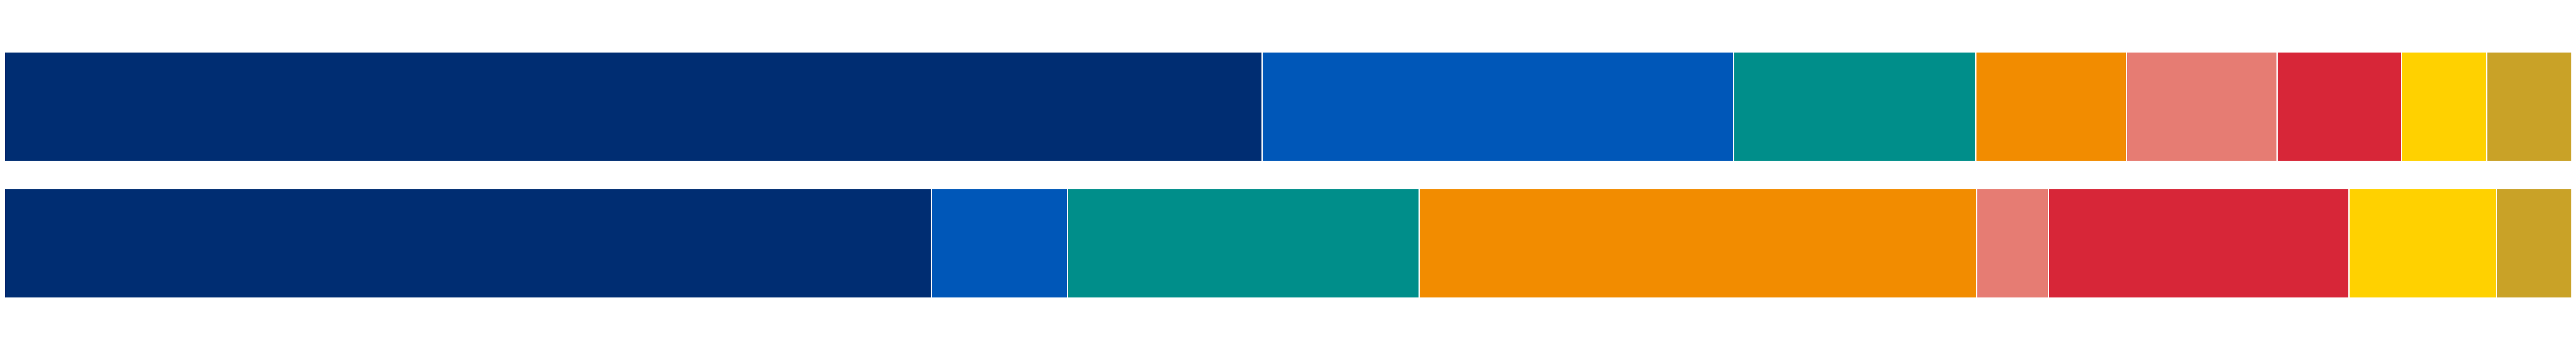

In [15]:
porthcawl_counts = df["Incident_Category"].value_counts()
wales_counts = df2["Incident_Category"].value_counts()

# Keep a consistent category order:
# use Porthcawl order first, then add any extra Wales categories
categories = list(porthcawl_counts.index)

for cat in wales_counts.index:
    if cat not in categories:
        categories.append(cat)

# Reindex so both series have the same categories
porthcawl_counts = porthcawl_counts.reindex(categories, fill_value=0)
wales_counts = wales_counts.reindex(categories, fill_value=0)

porthcawl_total = porthcawl_counts.sum()
wales_total = wales_counts.sum()


# Create figure and axis

fig, ax = plt.subplots(figsize=(60, 8))


# Set up RNLI-inspired colours

rnli_palette = [
    "#002D72",  # Deep Navy
    "#0057B8",  # Sea Blue
    "#008E8A",  # Marine Teal
    "#F28C00",  # RNLI Orange
    "#E67C73",  # Salmon Red
    "#D72638",  # Rescue Red
    "#FFD100",  # Signal Yellow
    "#C9A227"   # Gold
]

colors = rnli_palette[:len(categories)]
color_map = dict(zip(categories, colors))


# Function to draw one clean stacked row

def draw_stacked_row(ax, counts, total, y_position):
    current_left_pct = 0

    for cat in categories:
        val = counts[cat]
        pct = (val / total) * 100 if total > 0 else 0

        ax.barh(
            y_position,
            pct,
            left=current_left_pct,
            color=color_map[cat],
            edgecolor="white",
            linewidth=2,
            height=0.8
        )

        current_left_pct += pct


# Draw Porthcawl and Wales

draw_stacked_row(ax, porthcawl_counts, porthcawl_total, y_position=1)
draw_stacked_row(ax, wales_counts, wales_total, y_position=0)


# Remove all labels, ticks, titles, legends, axes

ax.set_xlim(0, 100)
ax.set_ylim(-0.75, 1.75)

ax.set_xticks([])
ax.set_yticks([])

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.axis("off")

plt.tight_layout(pad=0)

# Save clean output

plt.savefig(
    "porthcawl_wales_clean_combination.png",
    transparent=True,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

# Main 100% Vertical Stacked Bar Charts - Labelled

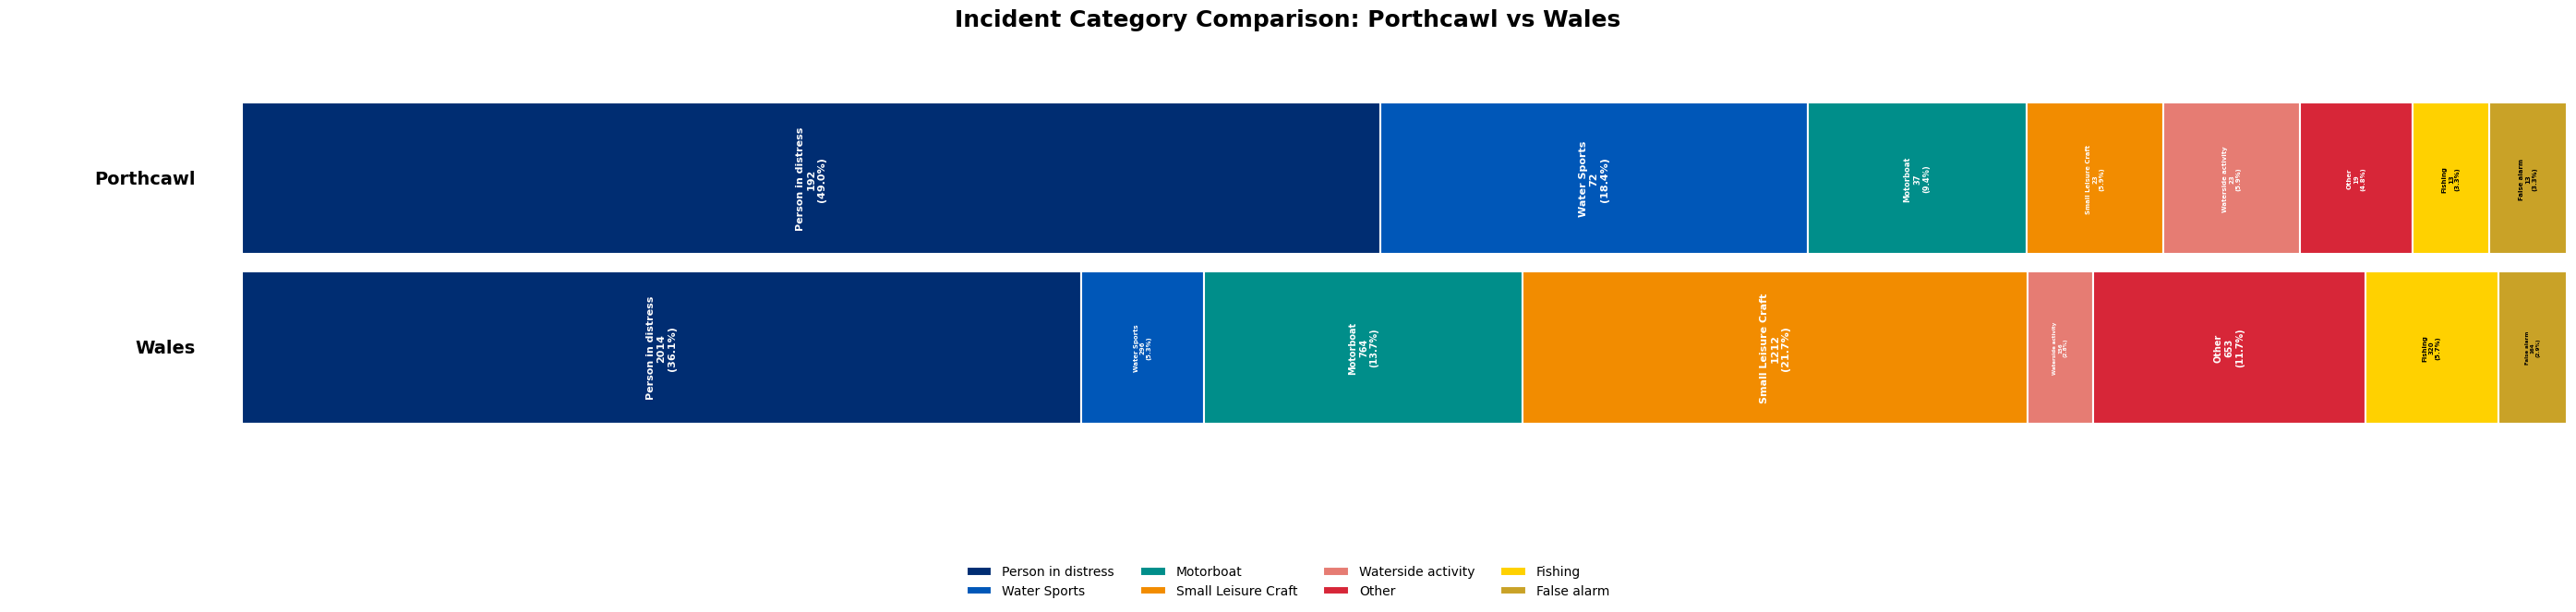

In [16]:

porthcawl_counts = df["Incident_Category"].value_counts()
wales_counts = df2["Incident_Category"].value_counts()

# Keep a consistent category order:
# use Porthcawl order first, then add any extra Wales categories
categories = list(porthcawl_counts.index)

for cat in wales_counts.index:
    if cat not in categories:
        categories.append(cat)

# Reindex so both series have the same categories
porthcawl_counts = porthcawl_counts.reindex(categories, fill_value=0)
wales_counts = wales_counts.reindex(categories, fill_value=0)

porthcawl_total = porthcawl_counts.sum()
wales_total = wales_counts.sum()


fig, ax = plt.subplots(figsize=(28, 7))


# Set up RNLI-inspired colours

rnli_palette = [
    "#002D72",  # Deep Navy
    "#0057B8",  # Sea Blue
    "#008E8A",  # Marine Teal
    "#F28C00",  # RNLI Orange
    "#E67C73",  # Salmon Red
    "#D72638",  # Rescue Red
    "#FFD100",  # Signal Yellow
    "#C9A227"   # Gold
]

# Extend palette if needed
if len(categories) > len(rnli_palette):
    extra_colors = plt.cm.tab20(np.linspace(0, 1, len(categories) - len(rnli_palette)))
    extra_colors = [plt.matplotlib.colors.to_hex(c) for c in extra_colors]
    colors = rnli_palette + extra_colors
else:
    colors = rnli_palette[:len(categories)]

color_map = dict(zip(categories, colors))

# Helper: choose readable text colour

def get_text_color(hex_color):
    r, g, b = to_rgb(hex_color)
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return "black" if luminance > 0.6 else "white"

# Function to draw one labelled stacked row

def draw_stacked_row(ax, counts, total, y_position, row_label):
    current_left_pct = 0

    for cat in categories:
        val = counts[cat]
        pct = (val / total) * 100 if total > 0 else 0

        if pct == 0:
            continue

        bar_color = color_map[cat]

        ax.barh(
            y_position,
            pct,
            left=current_left_pct,
            color=bar_color,
            edgecolor="white",
            linewidth=1.5,
            height=0.9,
            label=cat if y_position == 1 else ""
        )

        # Centre point of each segment
        label_x = current_left_pct + pct / 2

        # Dynamic font size based on segment width
        if pct >= 18:
            fs = 8
        elif pct >= 10:
            fs = 7
        elif pct >= 6:
            fs = 6
        elif pct >= 3:
            fs = 5
        else:
            fs = 4

        label_text = f"{cat}\n{val}\n({pct:.1f}%)"

        ax.text(
            label_x,
            y_position,
            label_text,
            ha="center",
            va="center",
            rotation=90,
            fontsize=fs,
            color=get_text_color(bar_color),
            fontweight="bold",
            clip_on=True
        )

        current_left_pct += pct

    # Row label on the left
    ax.text(
        -2,
        y_position,
        row_label,
        ha="right",
        va="center",
        fontsize=14,
        fontweight="bold"
    )


# Draw Porthcawl and Wales

draw_stacked_row(ax, porthcawl_counts, porthcawl_total, y_position=1, row_label="Porthcawl")
draw_stacked_row(ax, wales_counts, wales_total, y_position=0, row_label="Wales")


# Format chart

ax.set_xlim(-10, 100)
ax.set_ylim(-0.75, 1.75)

ax.set_xticks([])
ax.set_yticks([])

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(
    "Incident Category Comparison: Porthcawl vs Wales",
    fontsize=18,
    fontweight="bold",
    pad=20
)

for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.32),
    ncol=4,
    frameon=False,
    fontsize=10
)

plt.tight_layout()


# Save output

plt.savefig(
    "porthcawl_wales_rotated_labels_counts.png",
    transparent=True,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.2
)

plt.show()

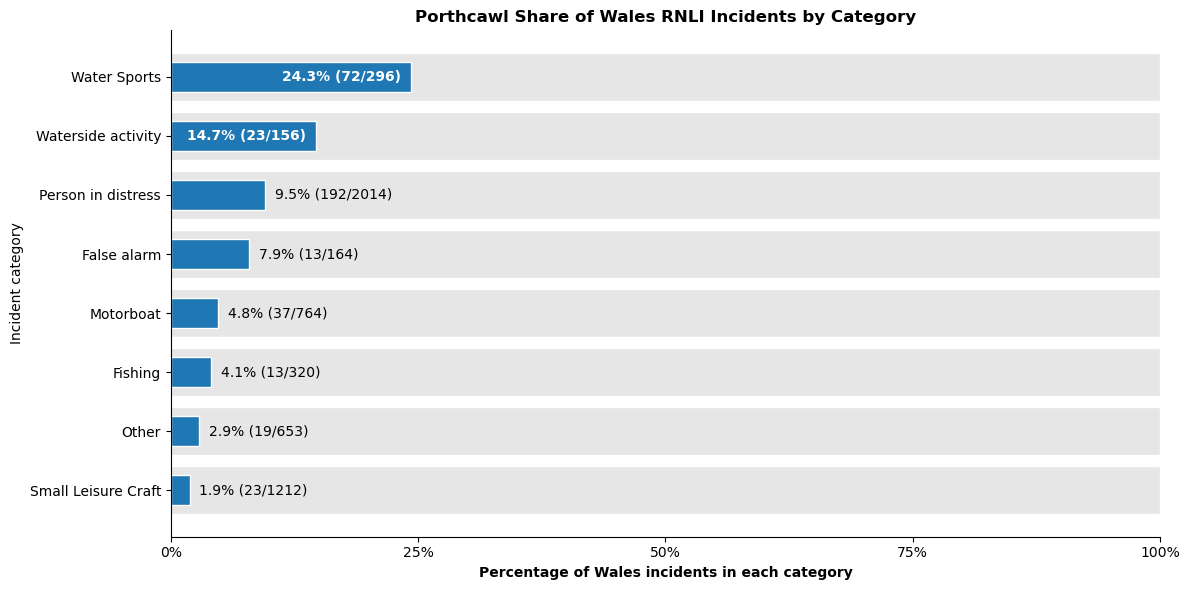

In [17]:
plot_df = comparison_df[comparison_df["Category"] != "Total"].copy()
plot_df = plot_df.sort_values(
    "Porthcawl Share of Wales Incidents (%)",
    ascending=True
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

# Wales background = 100%
ax.barh(
    plot_df["Category"],
    [100] * len(plot_df),
    color="#e6e6e6",
    edgecolor="white",
    height=0.8
)

# Porthcawl share
ax.barh(
    plot_df["Category"],
    plot_df["Porthcawl Share of Wales Incidents (%)"],
    color="#1f77b4",
    edgecolor="white",
    height=0.5
)

for i, row in plot_df.iterrows():
    share = row["Porthcawl Share of Wales Incidents (%)"]
    p_count = row["Porthcawl Raw Count"]
    w_count = row["Wales Raw Count"]
    label = f"{share:.1f}% ({p_count}/{w_count})"

    if share >= 12:
        ax.text(
            share - 1,
            i,
            label,
            ha="right",
            va="center",
            color="white",
            fontweight="bold"
        )
    else:
        ax.text(
            share + 1,
            i,
            label,
            ha="left",
            va="center",
            color="black"
        )

ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of Wales incidents in each category", fontweight="bold")
ax.set_ylabel("Incident category")
ax.set_title("Porthcawl Share of Wales RNLI Incidents by Category", fontweight="bold")

ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks([0, 25, 50, 75, 100])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Time Series Charts

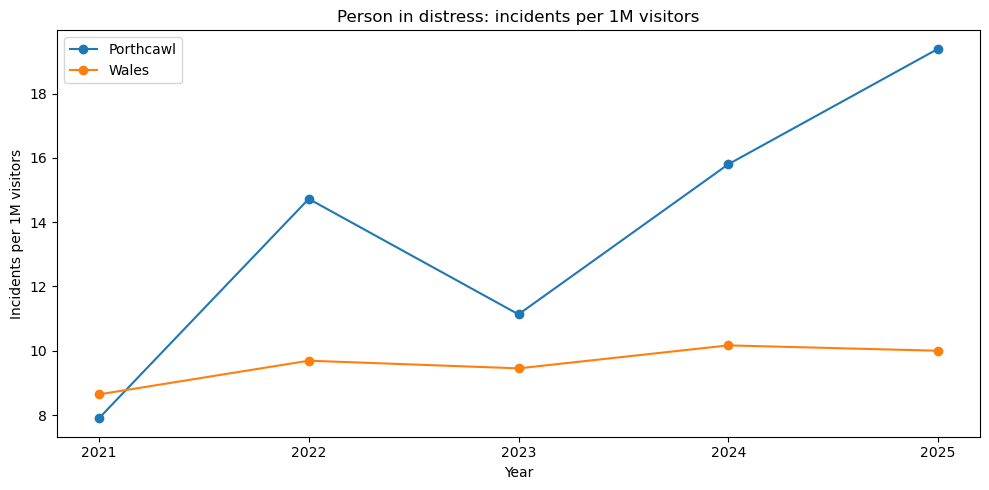

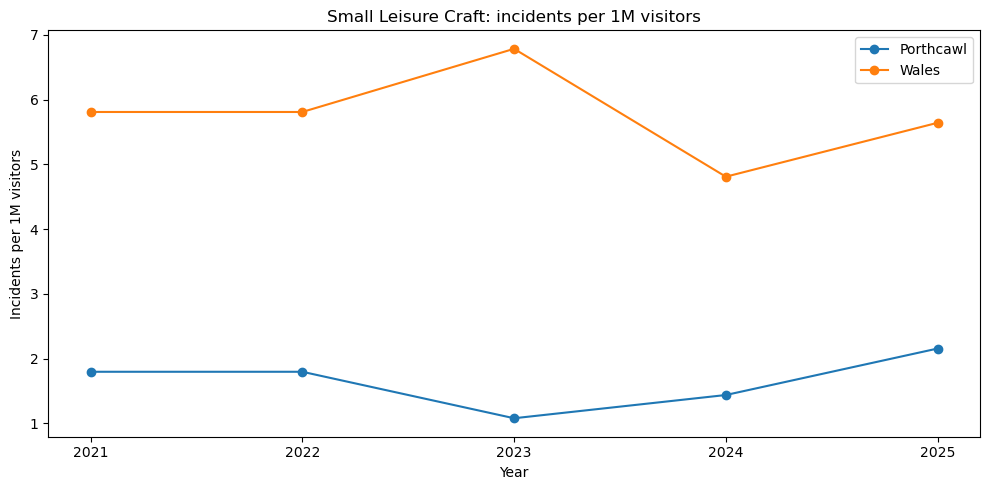

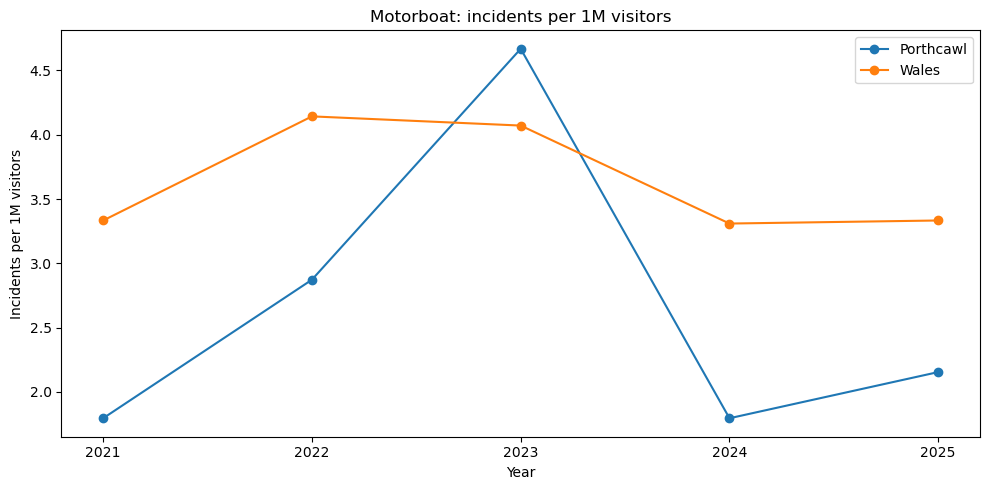

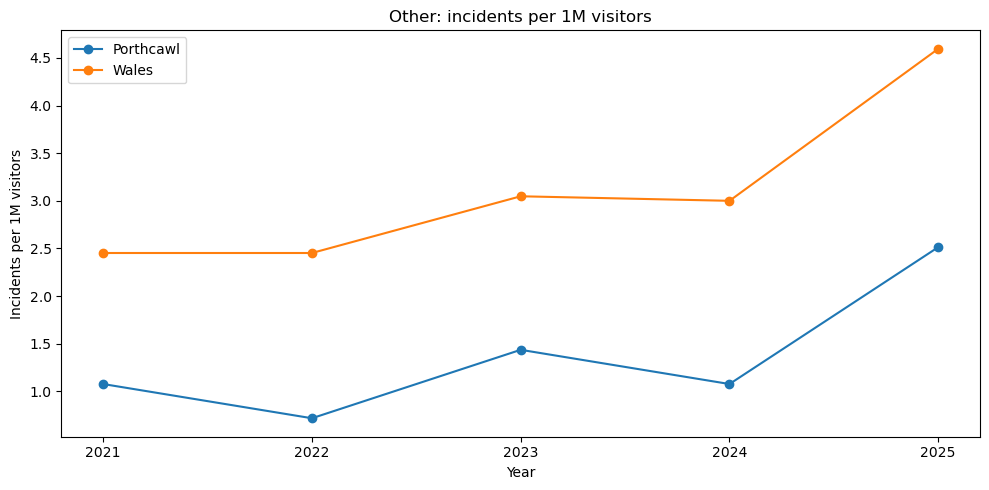

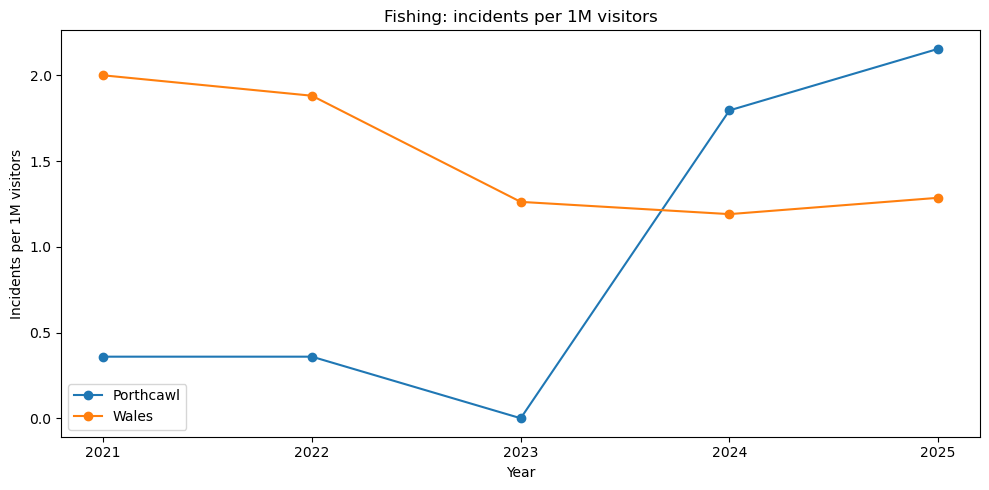

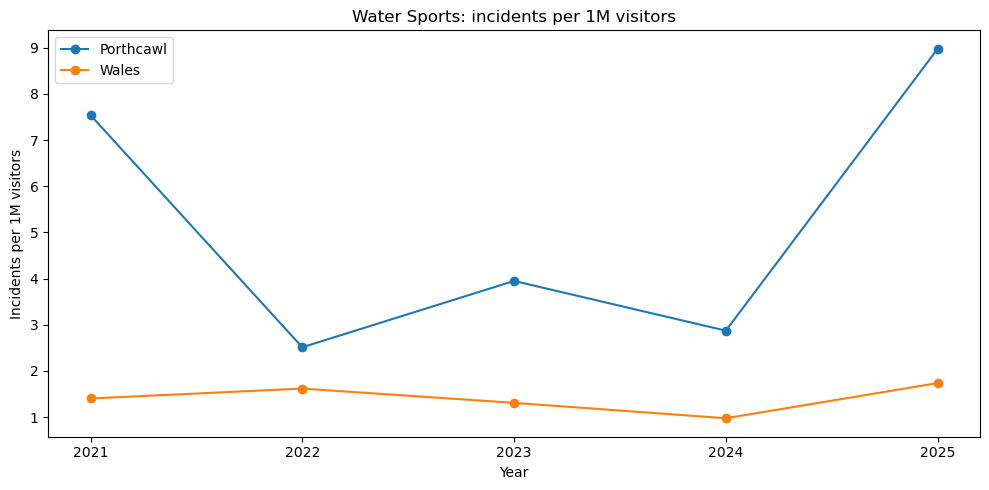

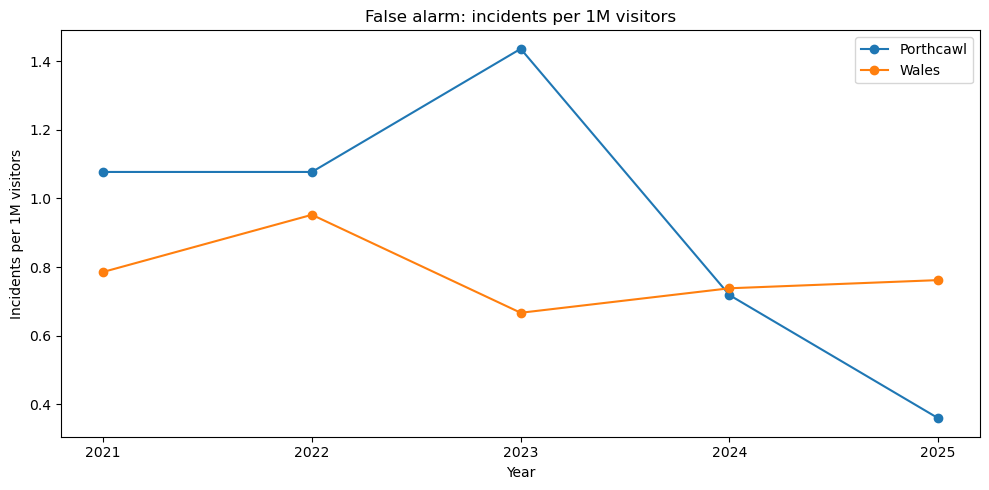

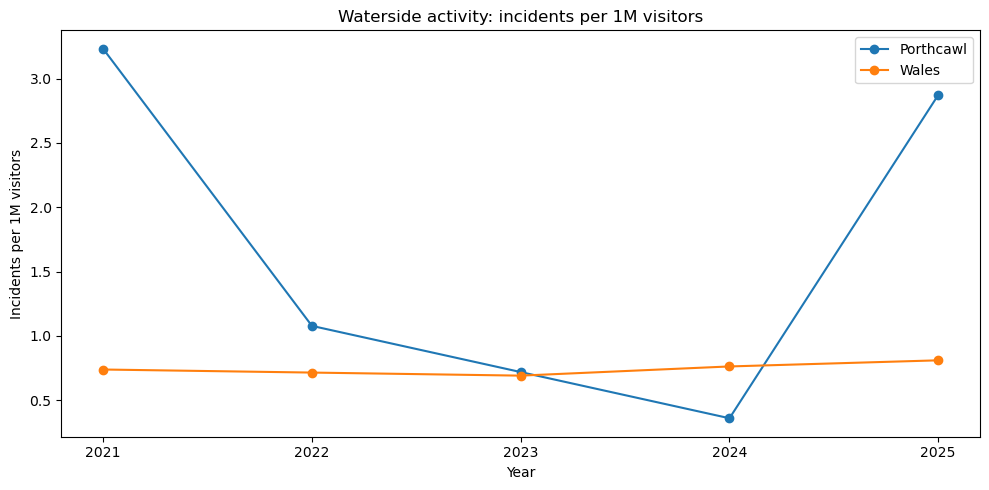

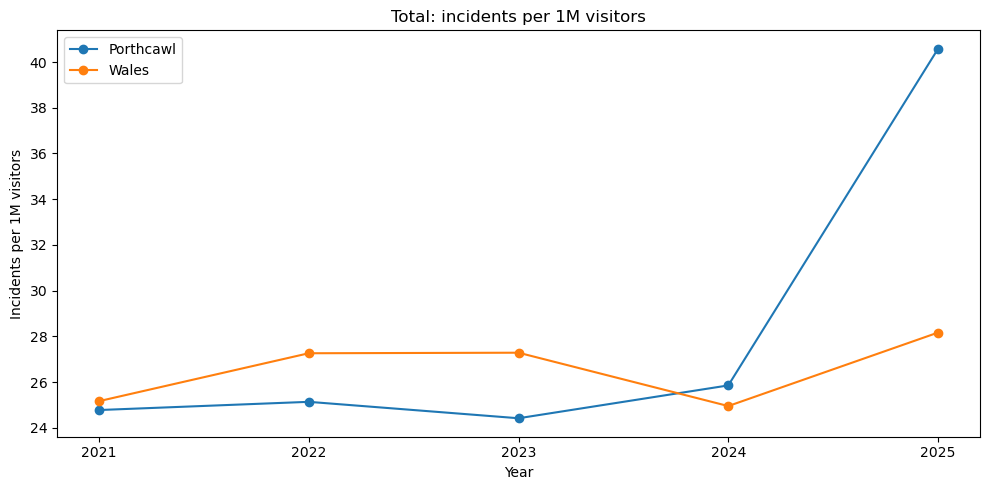

In [18]:
df2["Date of Launch"] = pd.to_datetime(df2["Date of Launch"], errors="coerce")
df2 = df2.dropna(subset=["Date of Launch"]).copy()
df2["Year"] = df2["Date of Launch"].dt.year

years = [2021, 2022, 2023, 2024, 2025]
df2 = df2[df2["Year"].isin(years)].copy()

if "Incident_Category" not in df2.columns:
    def map_incident_category(aic):
        if pd.isna(aic):
            return "Other"

        # Fishing
        if aic in ["Angler from boat", "Angler from shore", "Commercial fishing"]:
            return "Fishing"

        # False alarm
        if aic == "False alarm":
            return "False alarm"

        # Water sports
        if aic in [
            "Paddleboard", "Surfboard", "Bodyboard",
            "Kitesurf", "Windsurf", "Waterskier", "Scuba diver"
        ]:
            return "Water Sports"

        # Small leisure craft
        if aic in [
            "Sailing vessel", "Sailing dinghy", "Kayak/canoe",
            "Rowing boat", "Inflatable", "Diving vessel",
            "Unknown Craft", "Unknown craft"
        ]:
            return "Small Leisure Craft"

        # Motorboat
        if aic in ["Motorboat", "Jet ski"]:
            return "Motorboat"

        # Waterside activity
        if aic in ["Waterside activity", "Climber", "Tombstoner", "Coasteerer"]:
            return "Waterside activity"

        # Person in distress
        if aic in [
            "Person in distress", "Person in water", "Person ashore",
            "Person on craft", "Unknown person", "Walker/runner", "Swimmer"
        ]:
            return "Person in distress"

        # Everything else
        return "Other"

    df2["Incident_Category"] = df2["AIC"].apply(map_incident_category)


# Annual beach visitor estimates
porthcawl_annual_visitors = 2_784_731
wales_annual_visitors = 42_000_000


# Preferred category order

category_order = [
    "Person in distress",
    "Small Leisure Craft",
    "Motorboat",
    "Other",
    "Fishing",
    "Water Sports",
    "False alarm",
    "Waterside activity"
]

# Keep only categories present
category_order = [c for c in category_order if c in df2["Incident_Category"].unique()]


# Build yearly count tables

# Wales counts by year/category
wales_counts = (
    df2.groupby(["Year", "Incident_Category"])
       .size()
       .unstack(fill_value=0)
       .reindex(index=years, fill_value=0)
)

# Porthcawl counts by year/category
porthcawl_counts = (
    df2[df2["LifeboatStationNameProper"] == "Porthcawl"]
      .groupby(["Year", "Incident_Category"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=years, fill_value=0)
)

# Make sure both have the same columns
for cat in category_order:
    if cat not in wales_counts.columns:
        wales_counts[cat] = 0
    if cat not in porthcawl_counts.columns:
        porthcawl_counts[cat] = 0

wales_counts = wales_counts[category_order]
porthcawl_counts = porthcawl_counts[category_order]


#  Convert to incidents per 1M visitors
# -----------------------------
wales_rates = wales_counts / wales_annual_visitors * 1_000_000
porthcawl_rates = porthcawl_counts / porthcawl_annual_visitors * 1_000_000

# Add total columns
wales_rates["Total"] = wales_counts.sum(axis=1) / wales_annual_visitors * 1_000_000
porthcawl_rates["Total"] = porthcawl_counts.sum(axis=1) / porthcawl_annual_visitors * 1_000_000


# Function to clean file names

def slugify(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


# Plot one chart per category + Total

plot_categories = category_order + ["Total"]

for cat in plot_categories:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(years, porthcawl_rates[cat], marker="o", label="Porthcawl")
    ax.plot(years, wales_rates[cat], marker="o", label="Wales")

    ax.set_title(f"{cat}: incidents per 1M visitors")
    ax.set_xlabel("Year")
    ax.set_ylabel("Incidents per 1M visitors")
    ax.set_xticks(years)
    ax.legend()

    plt.tight_layout()

    file_name = f"time_series_per_1m_{slugify(cat)}.png"
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

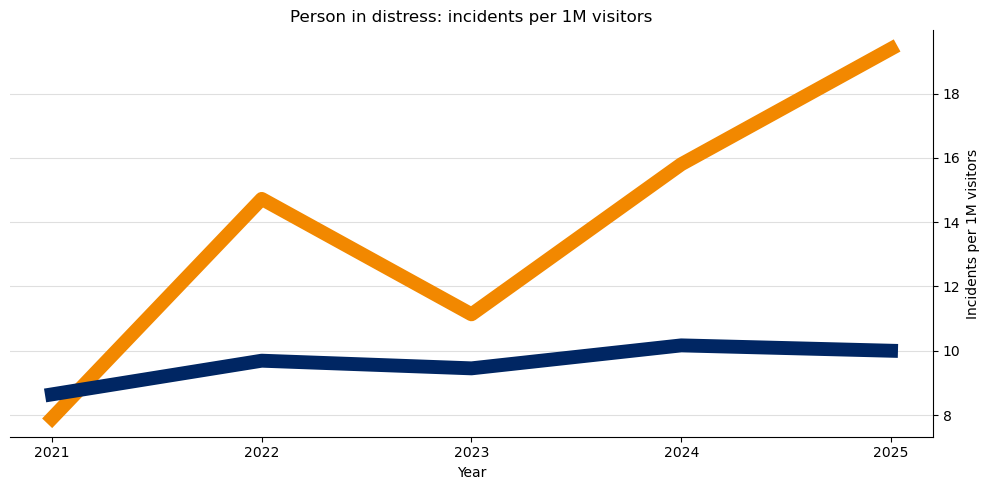

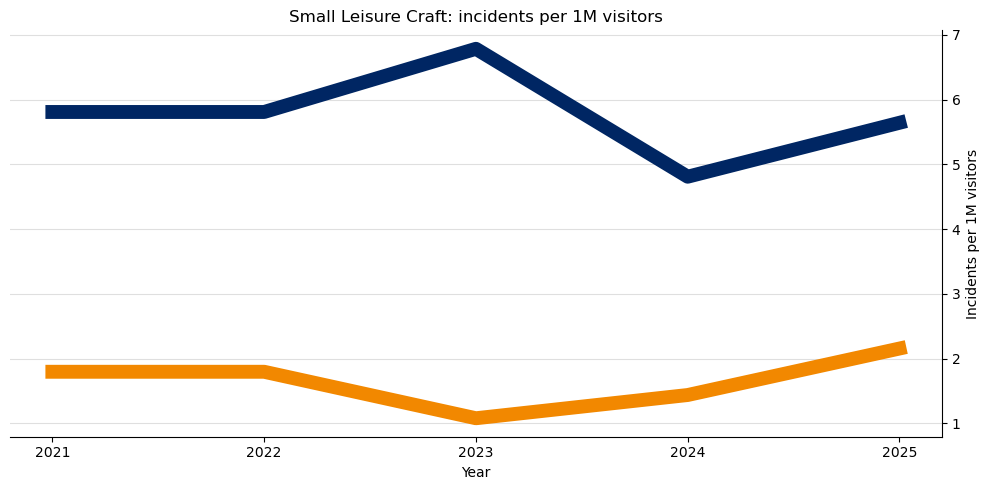

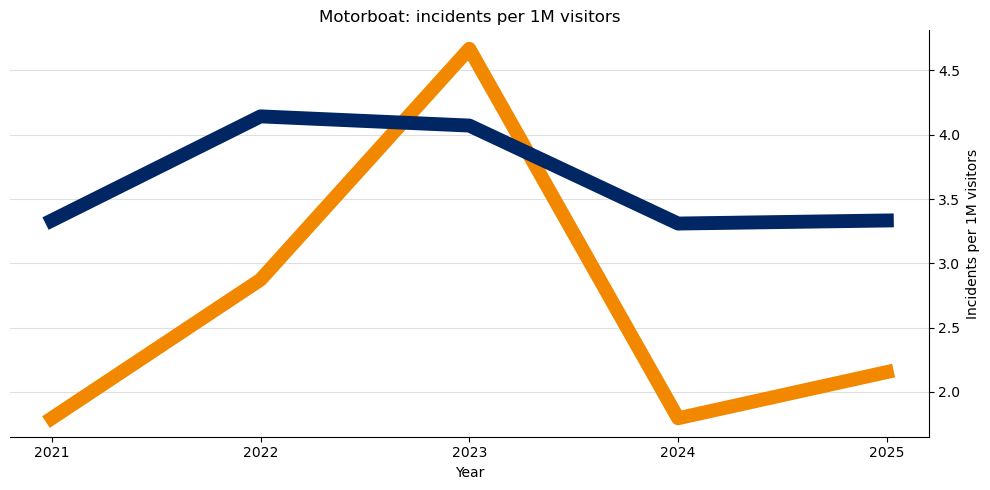

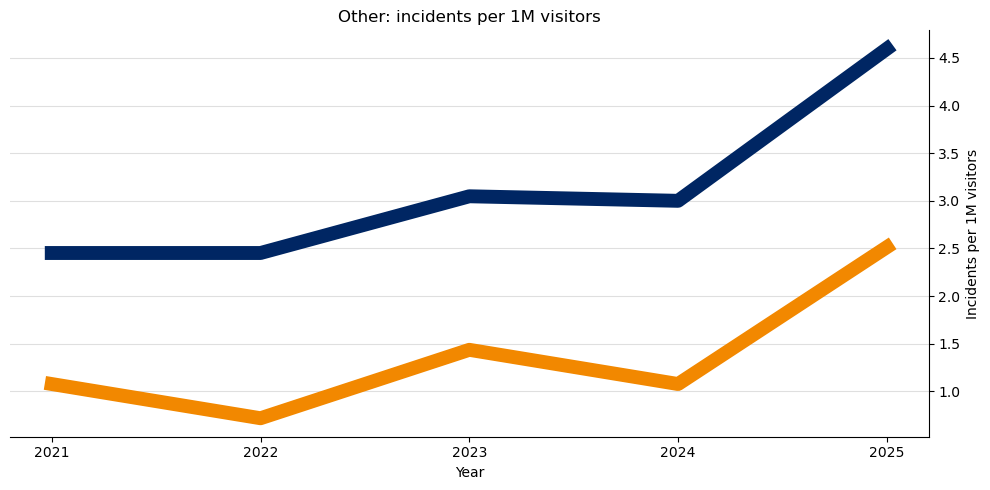

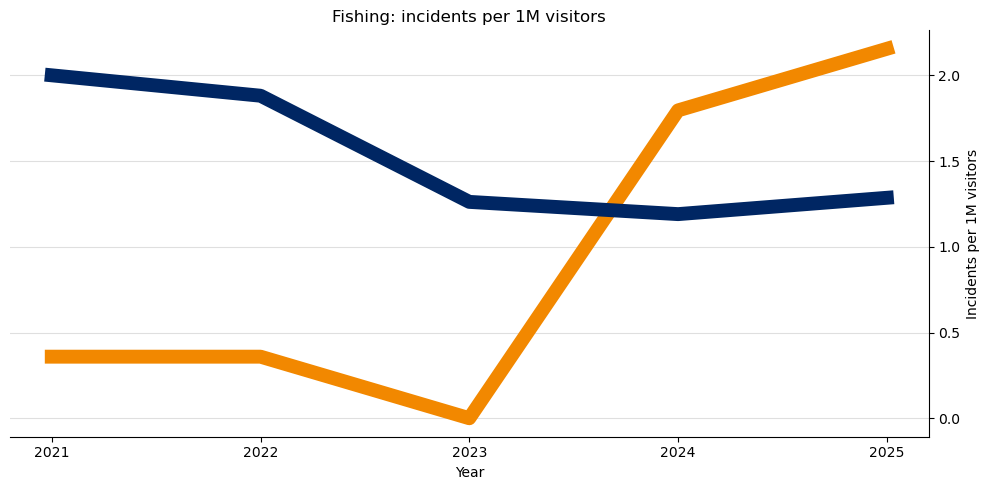

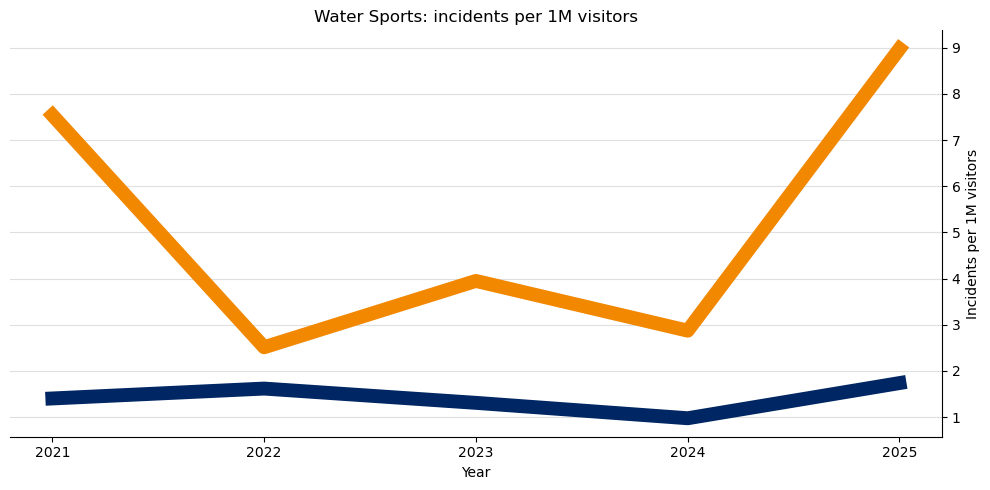

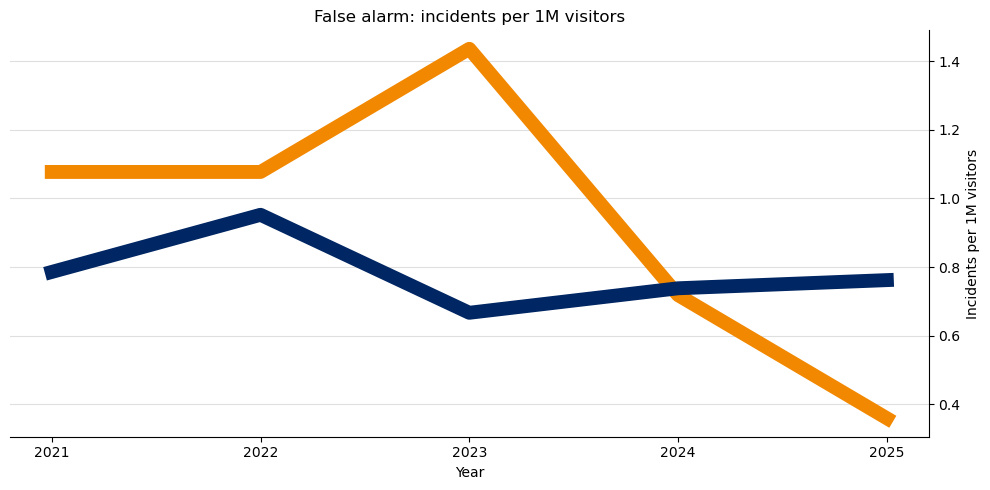

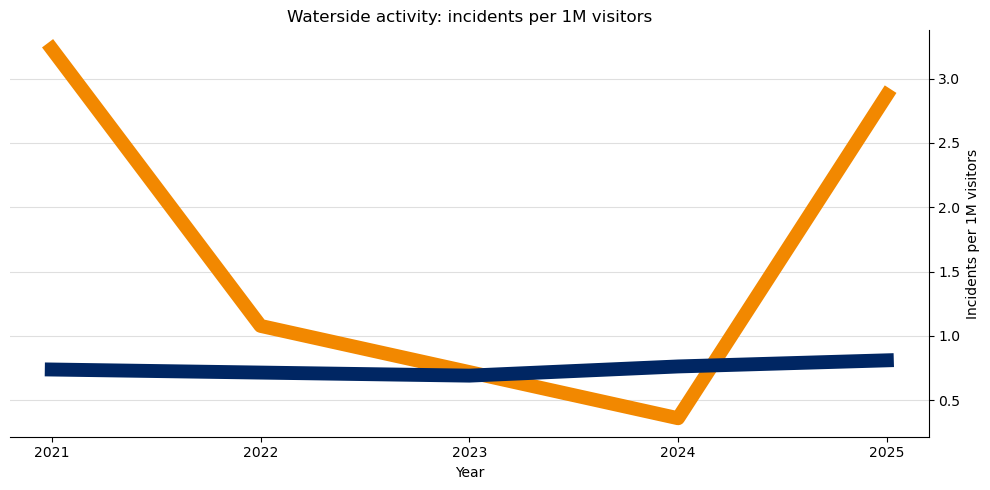

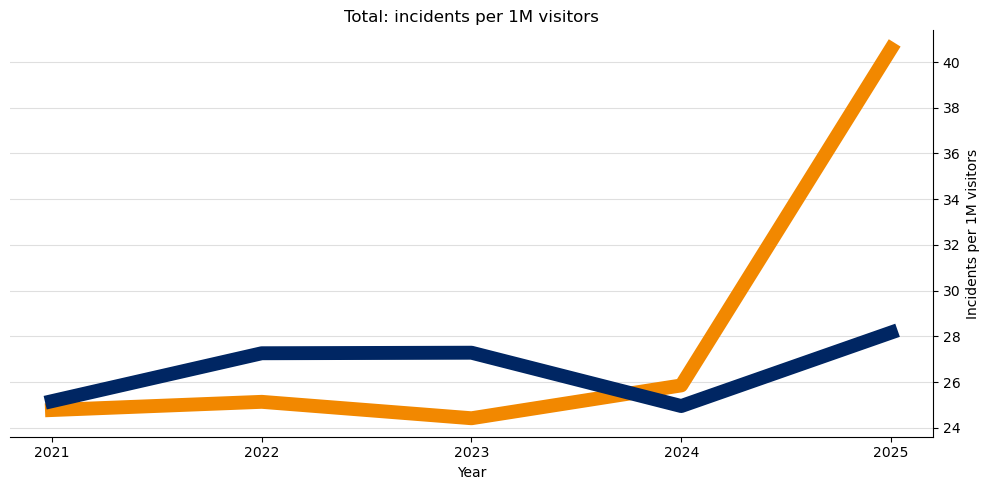

In [19]:
# Plot one chart per category + Total
category_order = [
    "Person in distress",
    "Small Leisure Craft",
    "Motorboat",
    "Other",
    "Fishing",
    "Water Sports",
    "False alarm",
    "Waterside activity"]

plot_categories = category_order + ["Total"]

for cat in plot_categories:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Make figure and axes background transparent
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    ax.plot(
        years,
        porthcawl_rates[cat],
        linewidth=10,
        color="#f28800",
        zorder=3
    )

    ax.plot(
        years,
        wales_rates[cat],
        linewidth=10,
        color="#002663",
        zorder=3
    )

    ax.set_title(f"{cat}: incidents per 1M visitors")
    ax.set_xlabel("Year")
    ax.set_ylabel("Incidents per 1M visitors")
    ax.set_xticks(years)

    # Move y-axis ticks and label to the right
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.tick_params(axis="y", labelright=True, labelleft=False, right=True, left=False)

    # Hide left spine, keep right spine
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(True)

    # Faint horizontal grid lines
    ax.set_axisbelow(True)
    ax.grid(
        axis="y",
        color="grey",
        linestyle="-",
        linewidth=0.8,
        alpha=0.25
    )

    # Optional: make top axis line disappear too
    ax.spines["top"].set_visible(False)

    plt.tight_layout()

    file_name = f"time_series_per_1m_{slugify(cat)}.png"
    plt.savefig(
        file_name,
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )
    plt.show()

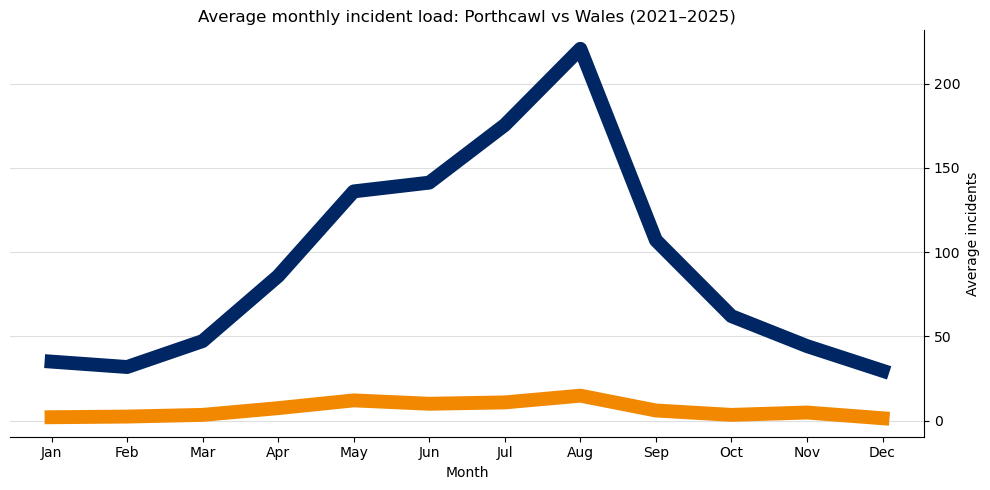

In [20]:
df2["Date of Launch"] = pd.to_datetime(df2["Date of Launch"], errors="coerce")
df2 = df2.dropna(subset=["Date of Launch"]).copy()

df2["Year"] = df2["Date of Launch"].dt.year
df2["Month"] = df2["Date of Launch"].dt.month

years = [2021, 2022, 2023, 2024, 2025]
df2 = df2[df2["Year"].isin(years)].copy()

station_col = "LifeboatStationNameProper"
target_station = "Porthcawl"

#Build full Year-Month index

full_month_index = pd.MultiIndex.from_product(
    [years, range(1, 13)],
    names=["Year", "Month"]
)


# Monthly counts: Porthcawl

porthcawl_monthly = (
    df2[df2[station_col] == target_station]
    .groupby(["Year", "Month"])
    .size()
    .reindex(full_month_index, fill_value=0)
    .reset_index(name="Count")
)

porthcawl_monthly_avg = (
    porthcawl_monthly
    .groupby("Month")["Count"]
    .mean()
    .reindex(range(1, 13), fill_value=0)
)


# Monthly counts: Wales

wales_monthly = (
    df2.groupby(["Year", "Month"])
    .size()
    .reindex(full_month_index, fill_value=0)
    .reset_index(name="Count")
)

wales_monthly_avg = (
    wales_monthly
    .groupby("Month")["Count"]
    .mean()
    .reindex(range(1, 13), fill_value=0)
)


#Plot

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Plot lines
ax.plot(
    range(1, 13),
    porthcawl_monthly_avg.values,
    linewidth=10,
    color="#f28800",
    zorder=3
)

ax.plot(
    range(1, 13),
    wales_monthly_avg.values,
    linewidth=10,
    color="#002663",
    zorder=3
)

# Titles and labels
ax.set_title("Average monthly incident load: Porthcawl vs Wales (2021–2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Average incidents")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)

# Move y-axis ticks and label to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.tick_params(axis="y", labelright=True, labelleft=False, right=True, left=False)

# Spine styling
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(True)
ax.spines["top"].set_visible(False)

# Faint horizontal grid lines
ax.set_axisbelow(True)
ax.grid(
    axis="y",
    color="grey",
    linestyle="-",
    linewidth=0.8,
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "monthly_average_porthcawl_vs_wales_2021_2025.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

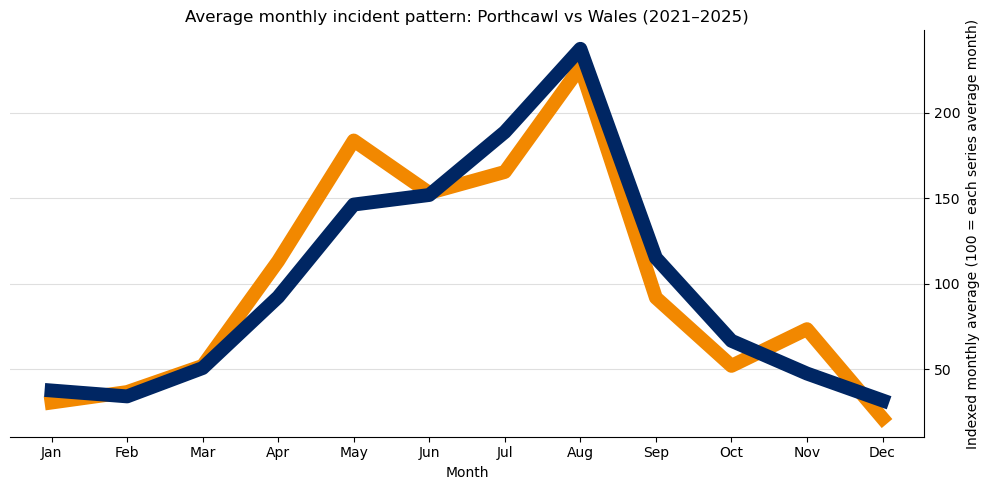

In [21]:

# Scale both series so average month = 100

porthcawl_index = (porthcawl_monthly_avg / porthcawl_monthly_avg.mean()) * 100
wales_index = (wales_monthly_avg / wales_monthly_avg.mean()) * 100

# -----------------------------
# 6. Plot
# -----------------------------
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Plot lines
ax.plot(
    range(1, 13),
    porthcawl_index.values,
    linewidth=10,
    color="#f28800",
    zorder=3
)

ax.plot(
    range(1, 13),
    wales_index.values,
    linewidth=10,
    color="#002663",
    zorder=3
)

# Titles and labels
ax.set_title("Average monthly incident pattern: Porthcawl vs Wales (2021–2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Indexed monthly average (100 = each series average month)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)

# Move y-axis ticks and label to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.tick_params(axis="y", labelright=True, labelleft=False, right=True, left=False)

# Spine styling
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(True)
ax.spines["top"].set_visible(False)

# Faint horizontal grid lines
ax.set_axisbelow(True)
ax.grid(
    axis="y",
    color="grey",
    linestyle="-",
    linewidth=0.8,
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "monthly_average_indexed_porthcawl_vs_wales_2021_2025.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

# Lollipop Charts

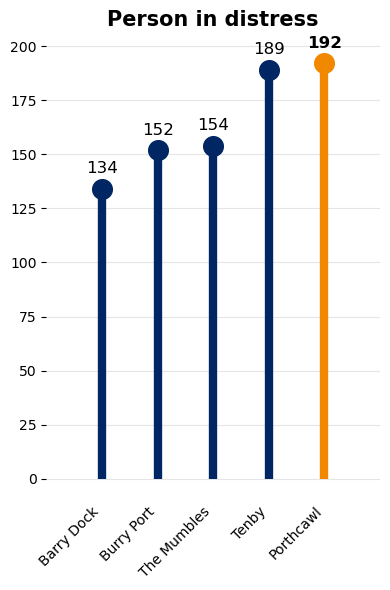

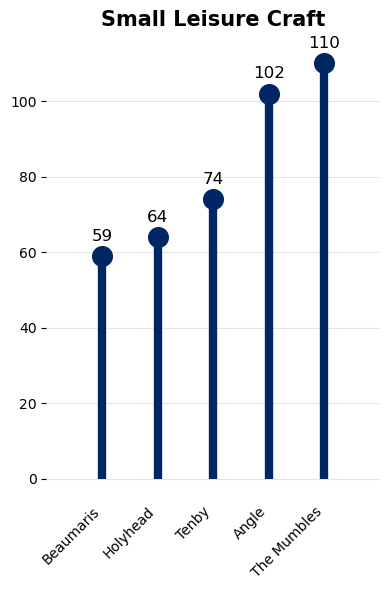

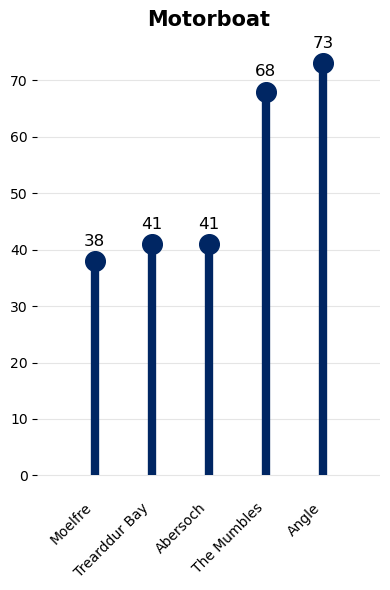

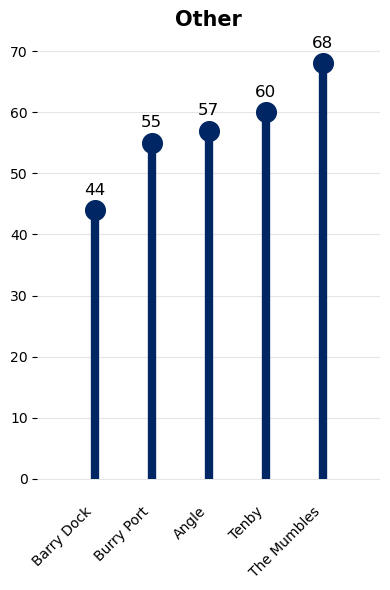

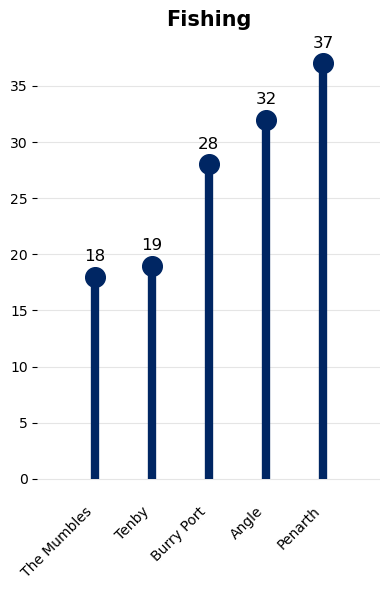

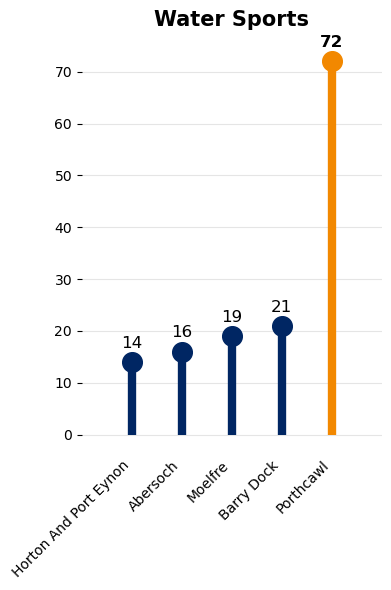

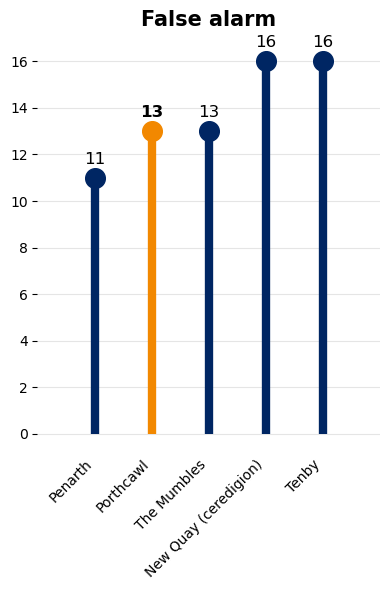

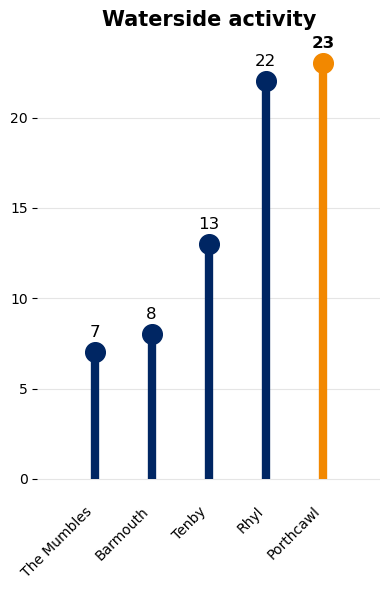

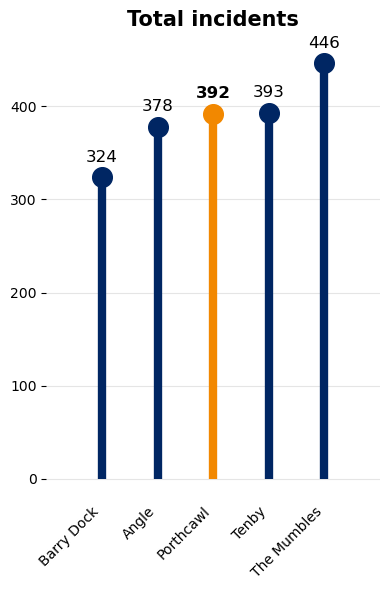

In [22]:
df2["Date of Launch"] = pd.to_datetime(df2["Date of Launch"], errors="coerce")
df2 = df2.dropna(subset=["Date of Launch"]).copy()
df2["Year"] = df2["Date of Launch"].dt.year

years = [2021, 2022, 2023, 2024, 2025]
df2 = df2[df2["Year"].isin(years)].copy()


# If Incident_Category does not exist, create it from AIC

if "Incident_Category" not in df2.columns:
    def map_incident_category(aic):
        if pd.isna(aic):
            return "Other"

        if aic in ["Angler from boat", "Angler from shore", "Commercial fishing"]:
            return "Fishing"

        if aic == "False alarm":
            return "False alarm"

        if aic in [
            "Paddleboard", "Surfboard", "Bodyboard",
            "Kitesurf", "Windsurf", "Waterskier", "Scuba diver"
        ]:
            return "Water Sports"

        if aic in [
            "Sailing vessel", "Sailing dinghy", "Kayak/canoe",
            "Rowing boat", "Inflatable", "Diving vessel",
            "Unknown Craft", "Unknown craft"
        ]:
            return "Small Leisure Craft"

        if aic in ["Motorboat", "Jet ski"]:
            return "Motorboat"

        if aic in ["Waterside activity", "Climber", "Tombstoner", "Coasteerer"]:
            return "Waterside activity"

        if aic in [
            "Person in distress", "Person in water", "Person ashore",
            "Person on craft", "Unknown person", "Walker/runner", "Swimmer"
        ]:
            return "Person in distress"

        return "Other"

    df2["Incident_Category"] = df2["AIC"].apply(map_incident_category)


# Basic cleaning

station_col = "LifeboatStationNameProper"
df2 = df2.dropna(subset=[station_col, "Incident_Category"]).copy()

category_order = [
    "Person in distress",
    "Small Leisure Craft",
    "Motorboat",
    "Other",
    "Fishing",
    "Water Sports",
    "False alarm",
    "Waterside activity"
]

category_order = [c for c in category_order if c in df2["Incident_Category"].unique()]


# Count incidents by station and category

station_cat_counts = (
    df2.groupby(["Incident_Category", station_col])
       .size()
       .reset_index(name="Incidents")
)

# Total incidents by station
station_total_counts = (
    df2.groupby(station_col)
       .size()
       .reset_index(name="Incidents")
)


# Helper for filenames

def slugify(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


# Style settings

default_line_color = "#002663"
default_dot_color = "#002663"
highlight_color = "#f28800"
grid_color = "grey"

target_station = "Porthcawl"
spacing = 0.25
stem_linewidth = 6


# Create one separate chart per incident type + Total

plot_categories = category_order + ["Total"]

for cat in plot_categories:
    if cat == "Total":
        top5 = (
            station_total_counts
            .sort_values("Incidents", ascending=False)
            .head(5)
            .sort_values("Incidents", ascending=True)
            .reset_index(drop=True)
        )
    else:
        top5 = (
            station_cat_counts[station_cat_counts["Incident_Category"] == cat]
            .sort_values("Incidents", ascending=False)
            .head(5)
            .sort_values("Incidents", ascending=True)
            .reset_index(drop=True)
        )

    fig, ax = plt.subplots(figsize=(4, 6))

    # Transparent background
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    # Make lollipops closer together
    x_positions = np.arange(len(top5)) * spacing
    max_value = top5["Incidents"].max()

    for x, (_, row) in zip(x_positions, top5.iterrows()):
        station = row[station_col]
        value = row["Incidents"]

        is_porthcawl = station == target_station

        line_color = highlight_color if is_porthcawl else default_line_color
        dot_color = highlight_color if is_porthcawl else default_dot_color
        text_weight = "bold" if is_porthcawl else "normal"

        # Lollipop stem
        ax.vlines(
            x=x,
            ymin=0,
            ymax=value,
            color=line_color,
            linewidth=stem_linewidth,
            zorder=2
        )

        # Lollipop head
        ax.scatter(
            x,
            value,
            s=200,
            color=dot_color,
            zorder=3
        )

        # Value label above each lollipop
        ax.text(
            x,
            value + max_value * 0.03,
            f"{value}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight=text_weight
        )

    # X labels = station names
    ax.set_xticks(x_positions)
    ax.set_xticklabels(top5[station_col], rotation=45, ha="right", fontsize=10)

    # Title
    if cat == "Total":
        ax.set_title("Total incidents", fontsize=15, fontweight="bold", pad=12)
    else:
        ax.set_title(cat, fontsize=15, fontweight="bold", pad=12)

    # Styling
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=grid_color, linewidth=0.8, alpha=0.2)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.tick_params(axis="x", length=0)

    # Tighten x-limits around closer spacing
    ax.set_xlim(x_positions.min() - 0.25, x_positions.max() + 0.25)

    plt.tight_layout()

    file_name = f"vertical_lollipop_top5_{slugify(cat)}.png"
    plt.savefig(
        file_name,
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )
    plt.show()

In [ ]:
#END